# Analyze Baselines

In [1]:
from pathlib import Path
import os
import json
from itertools import product

import pandas as pd

In [2]:
from temp import (
    mis_metrics,
    plot_mis_predictions
)

## Load Original Flows

In [3]:
# Configuration

dataset = "darpa2000"
scenario = "s1_inside"

# dataset = "aitv2"
# scenario = "fox"

out_dir = Path(f"../reports/baselines/{dataset}/{scenario}/temp")
out_dir.mkdir(parents=True, exist_ok=True)

In [4]:
df = pd.read_csv(
    f"../data/interim/{dataset}/{scenario}/flows_labeled/all_flows_labeled.csv"
)

df = df.sort_values("start_time").reset_index(drop=True)
df['t_rel'] = df['start_time'] - df['start_time'].min()

In [5]:
phase_bounds = (
    df[df['phase'] > 0]
    .groupby('phase')['t_rel']
    .agg(['min', 'max'])
)

phase_start = phase_bounds['min'].to_dict()
phase_end   = phase_bounds['max'].to_dict()

In [6]:
phase_bounds

,min,max
phase,,
1,1799.665435,1824.341042
2,2790.877254,3333.974143
3,4294.134775,4402.837414
4,5305.272464,5357.444592
5,7478.960660,8383.254878


## Temp Plots and Custom Metrics

In [7]:
models = [
    "multiclass",
    "ensemble",
]

file_paths = []

for model in models:
    folder = Path(f"../experiments/{dataset}/{scenario}/baselines/{model}/metrics/")
    file_paths.extend(list(folder.iterdir()))

print(len(file_paths))

40


Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


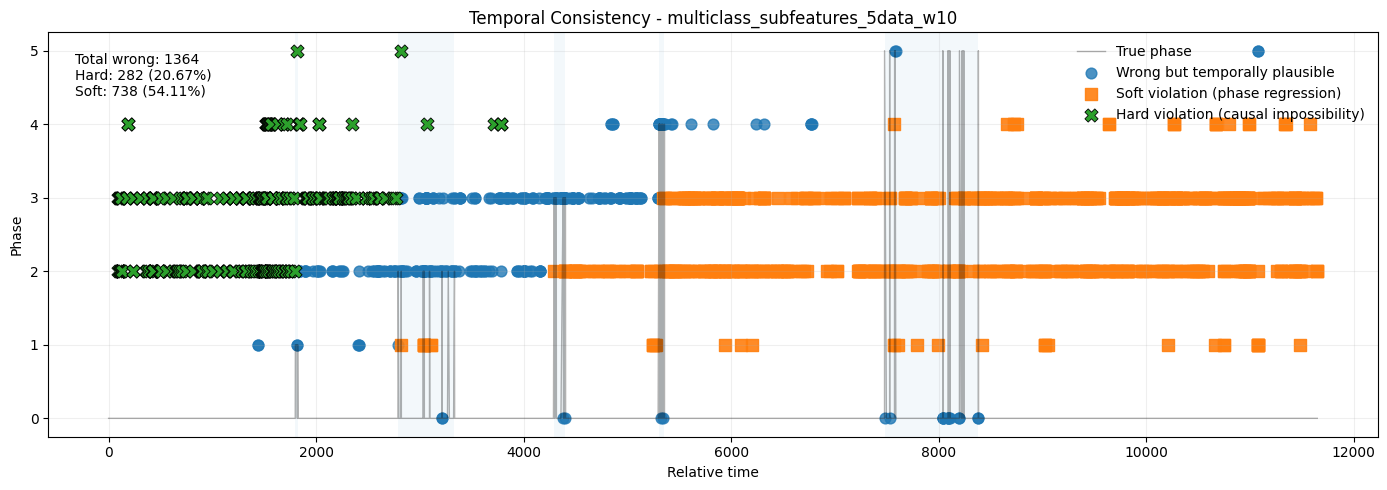

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


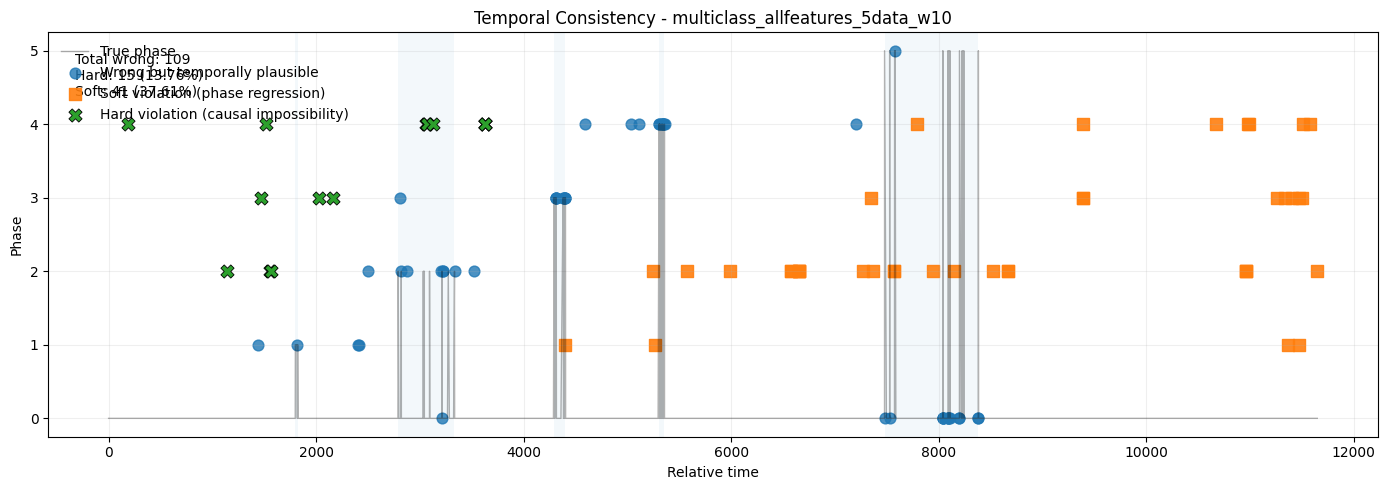

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


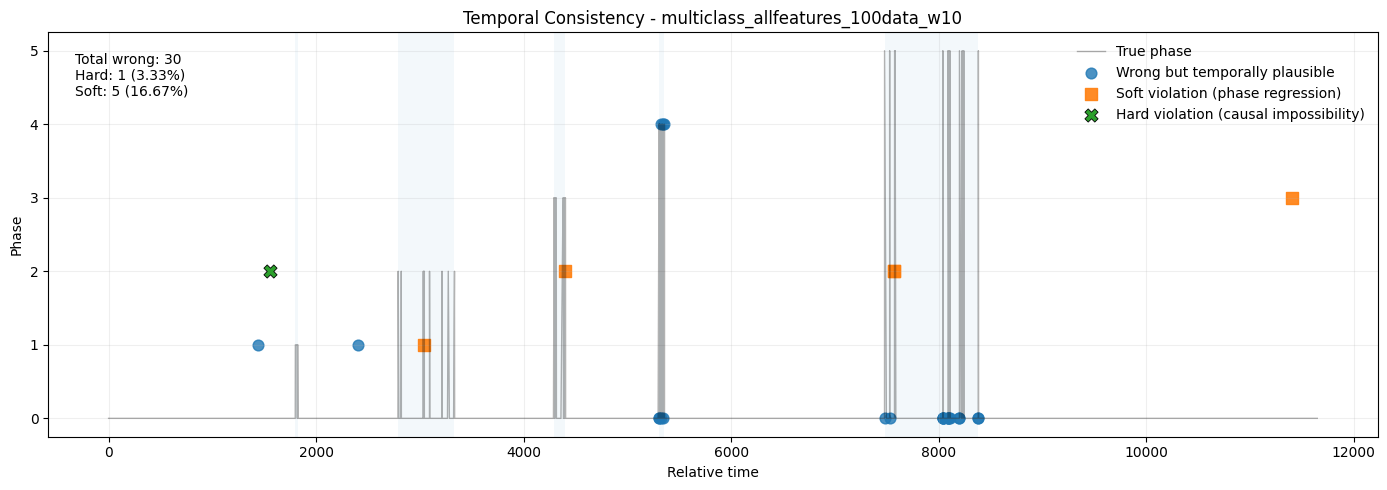

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


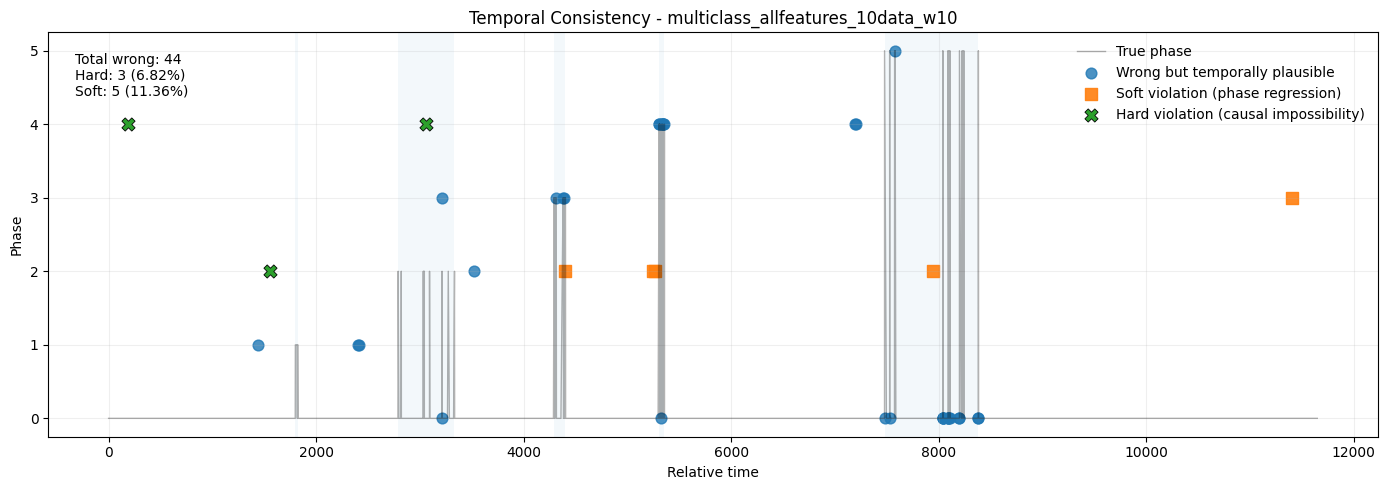

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


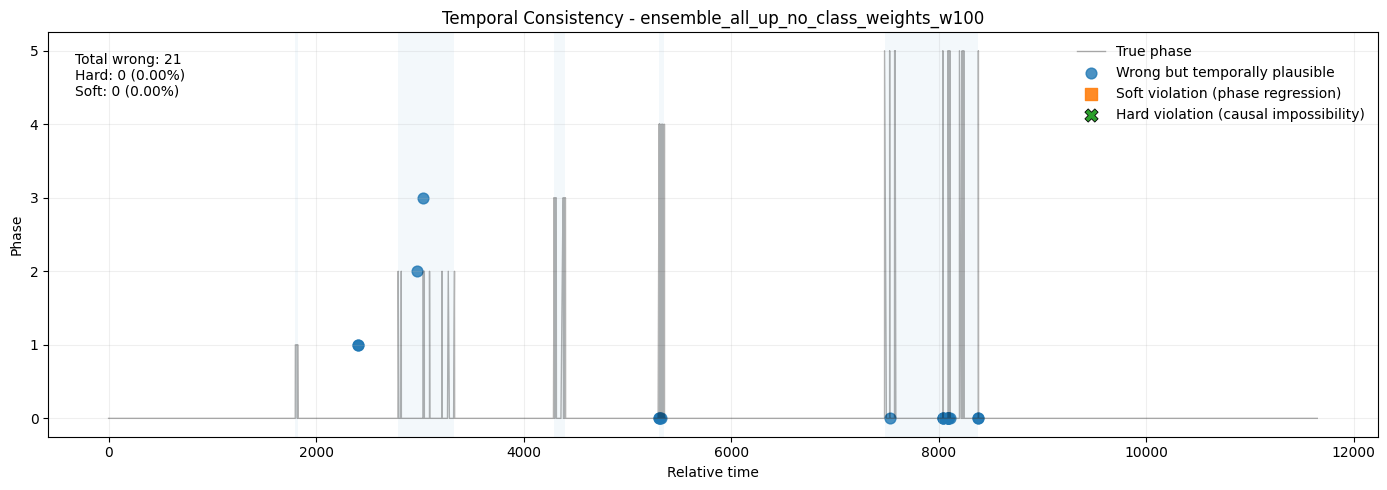

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


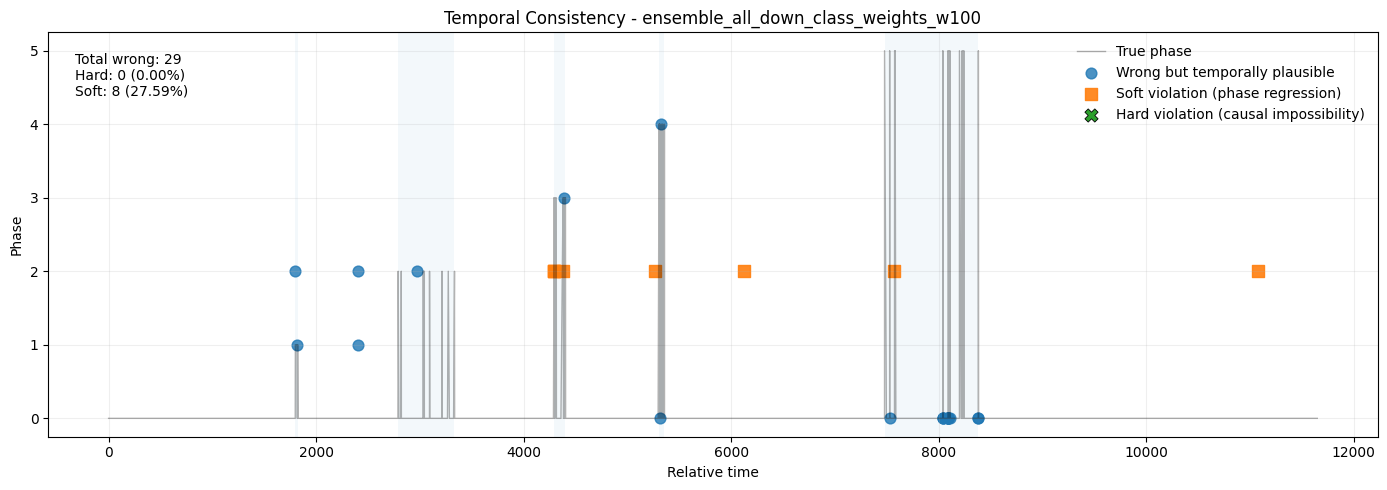

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


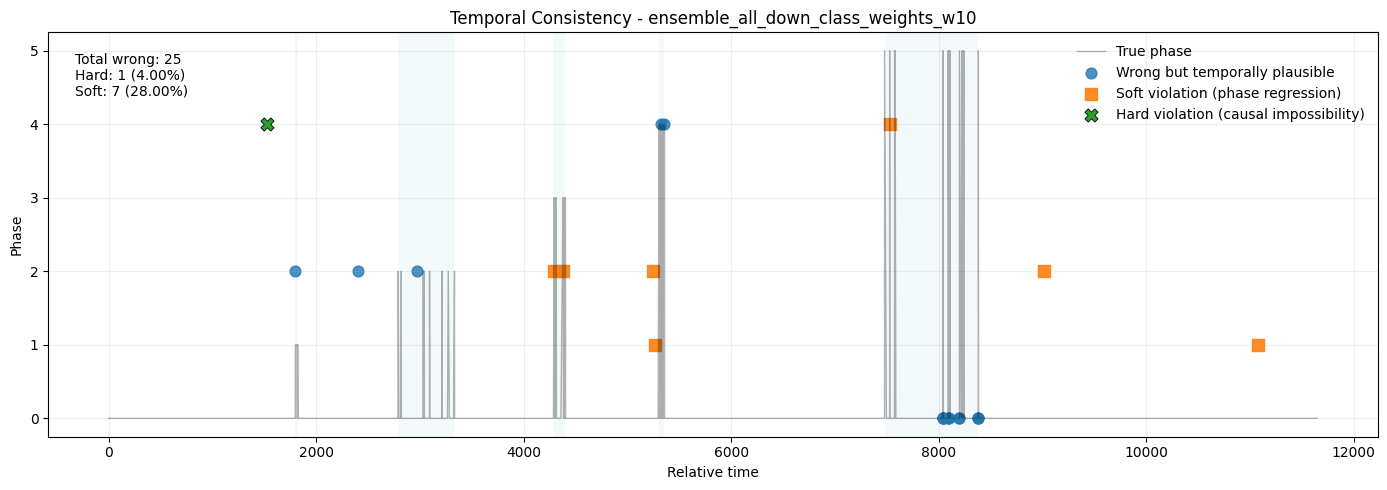

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


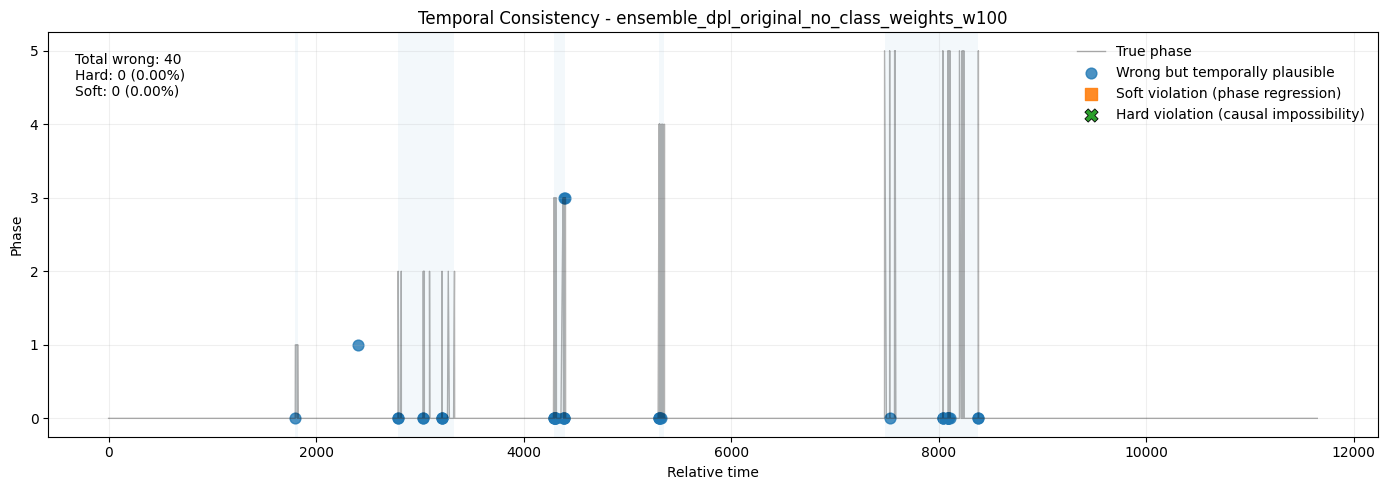

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


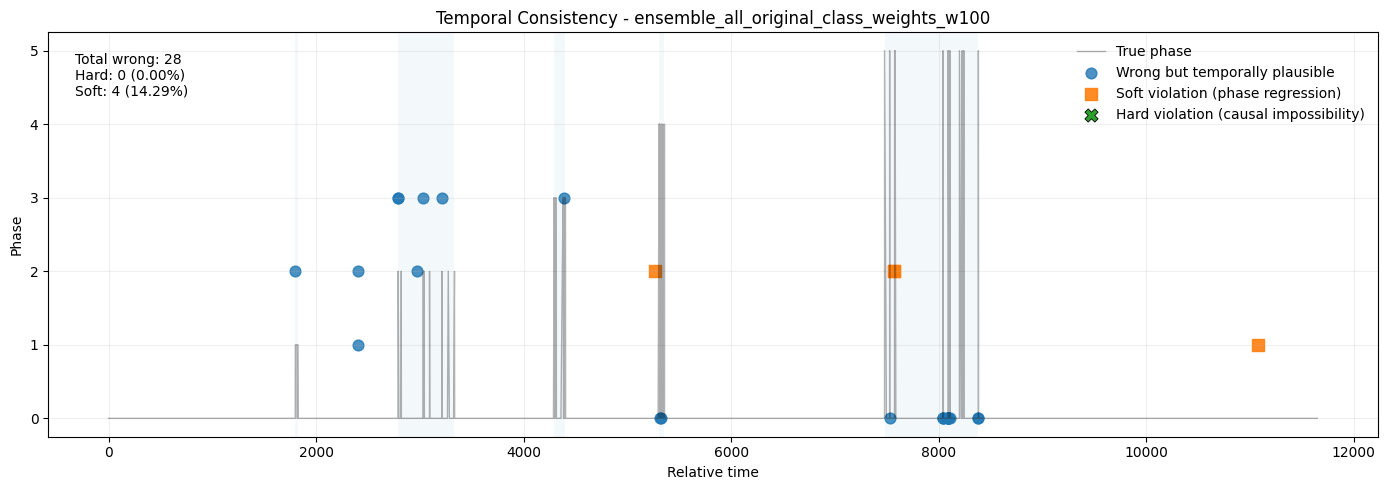

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


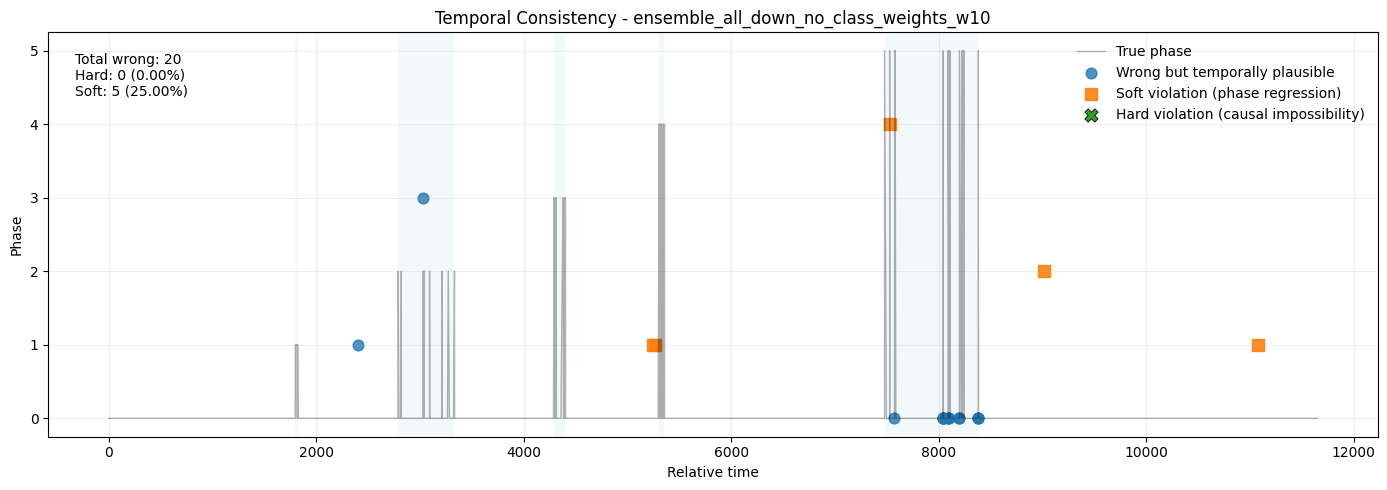

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


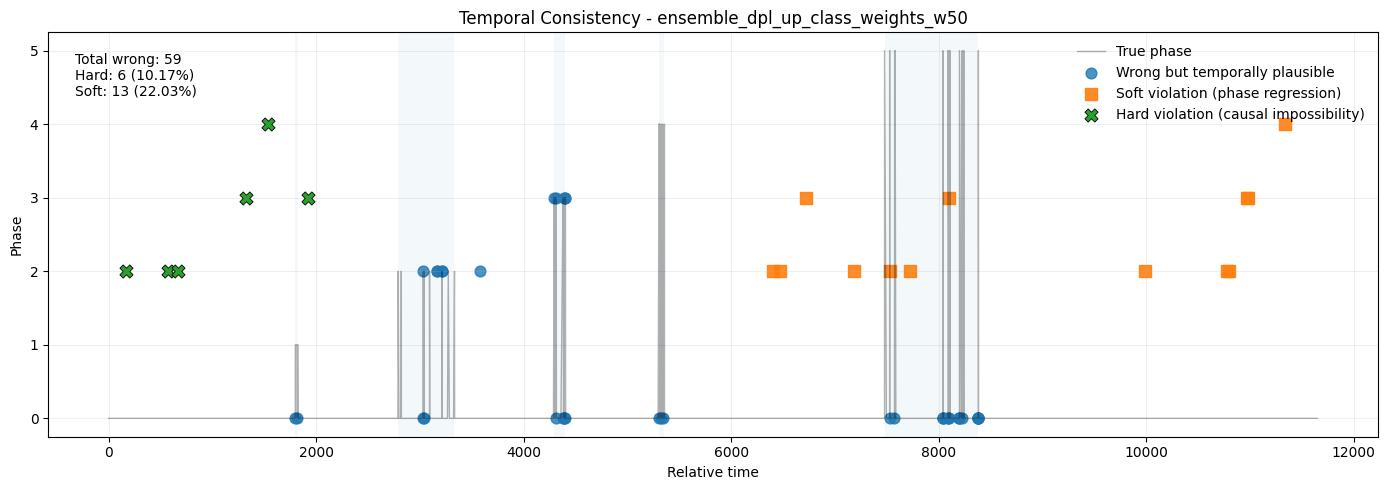

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


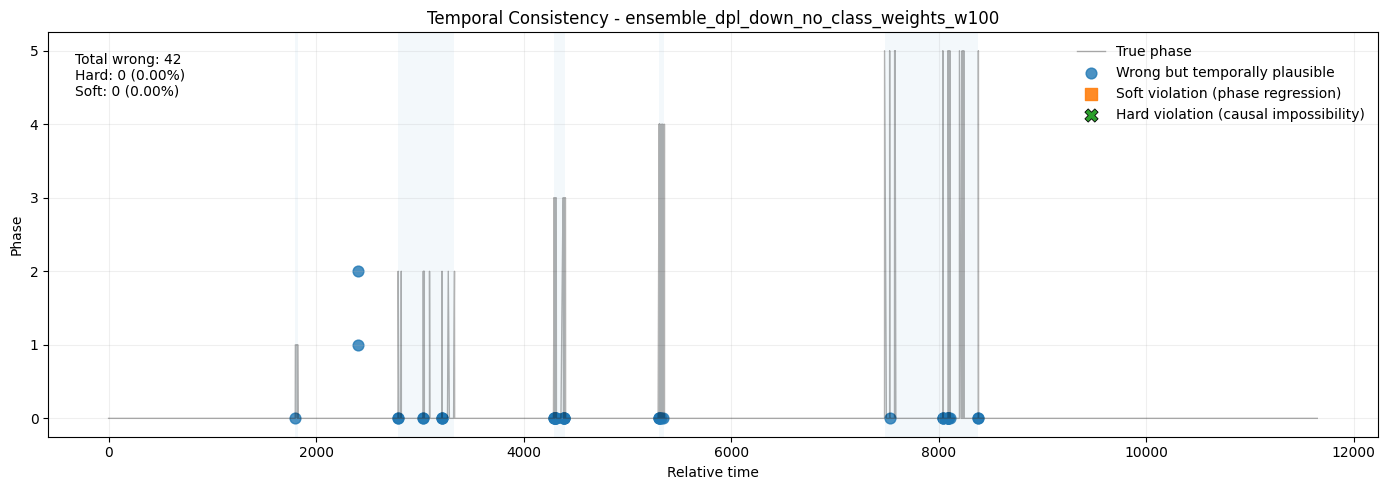

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


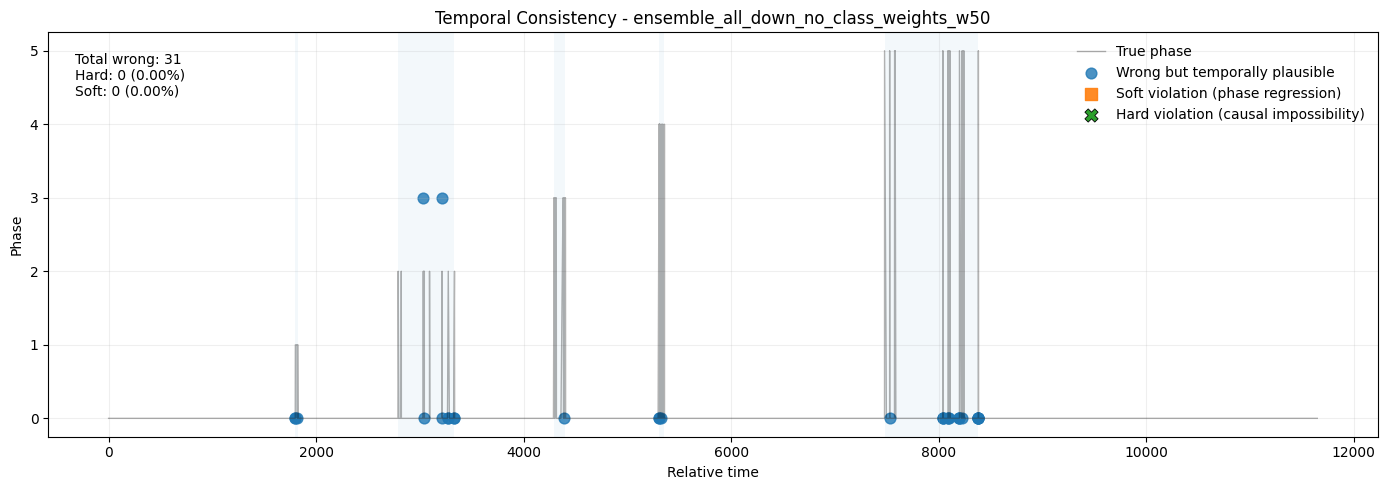

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


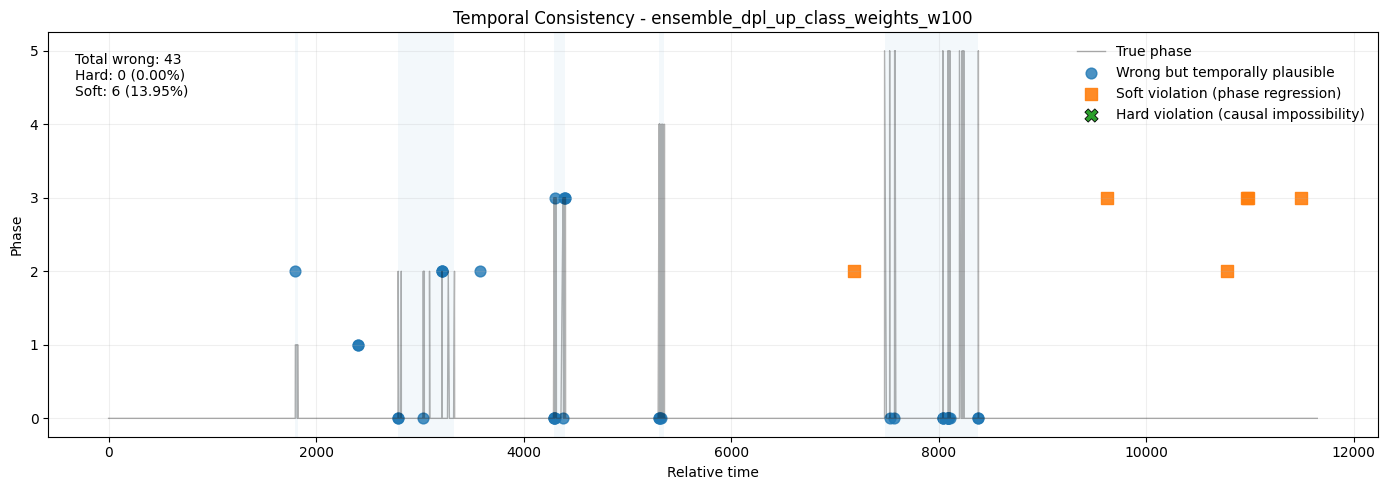

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


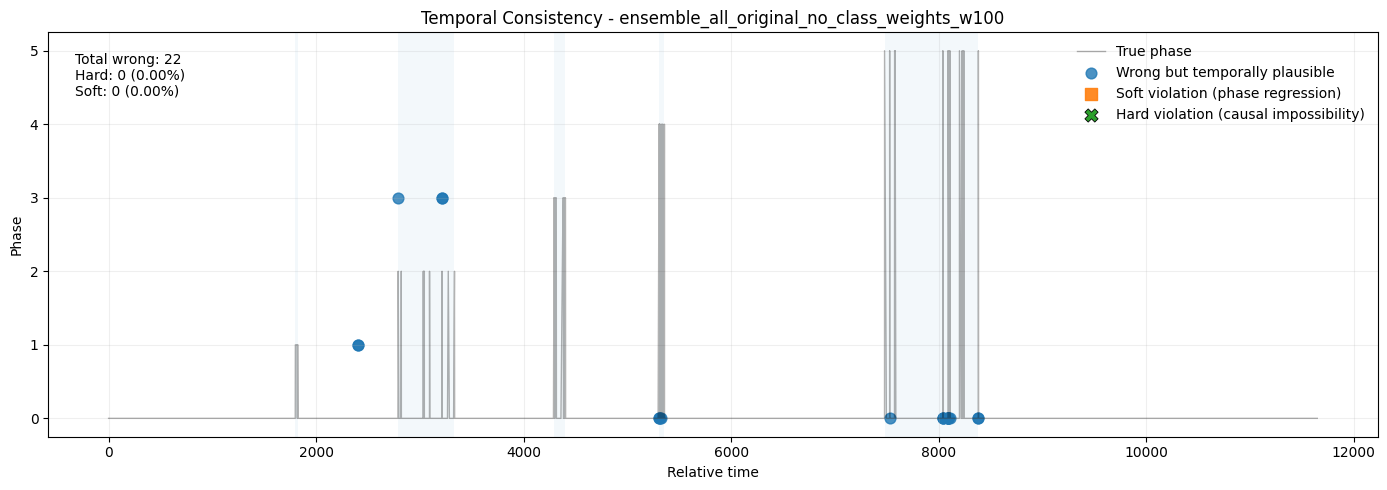

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


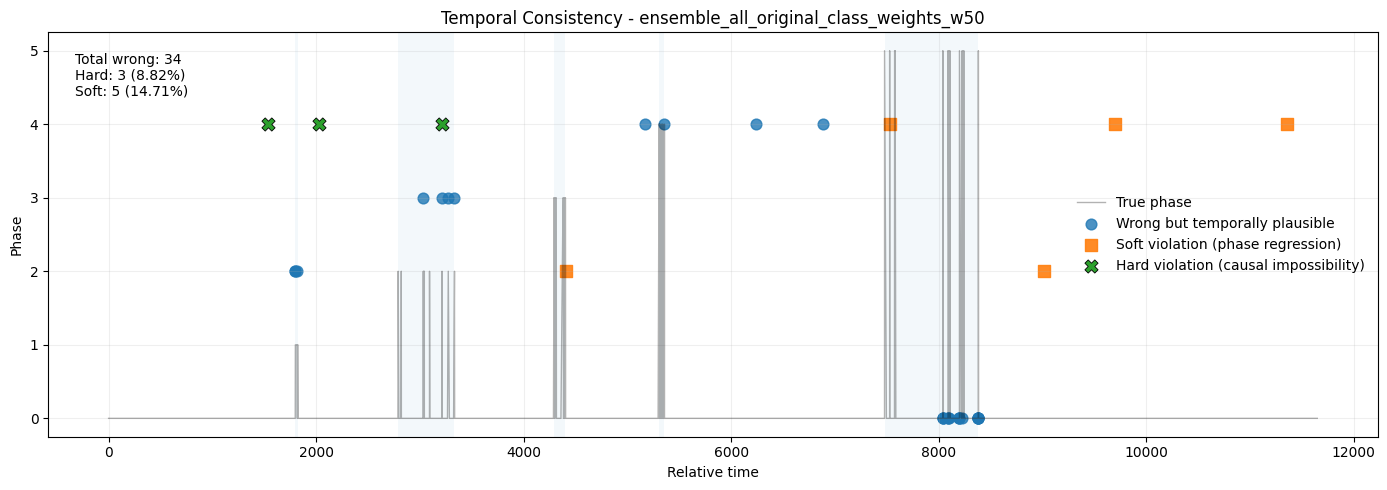

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


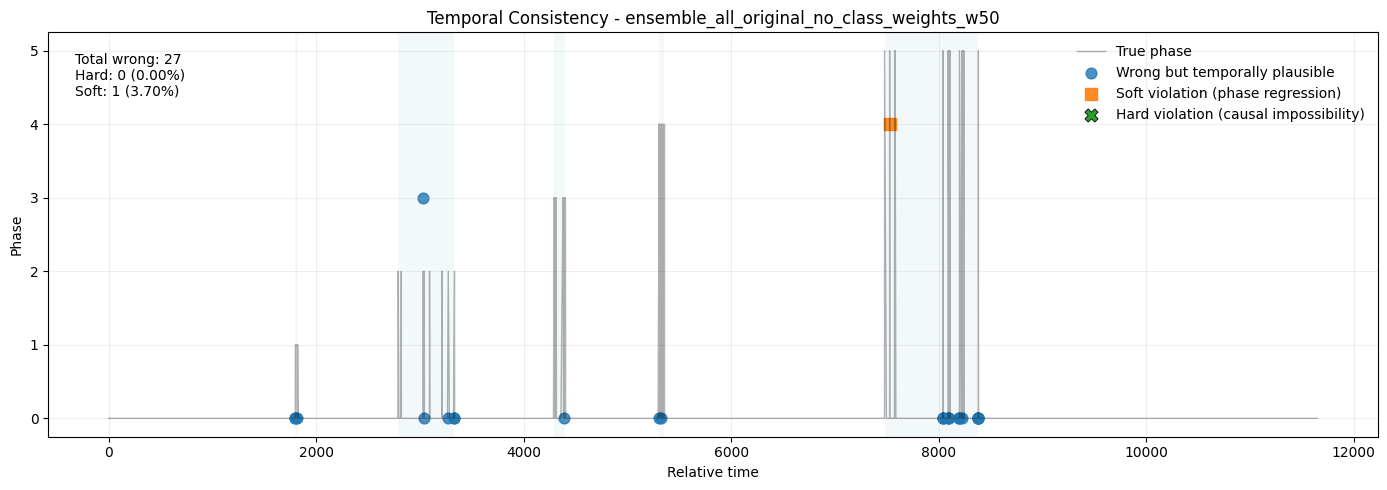

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


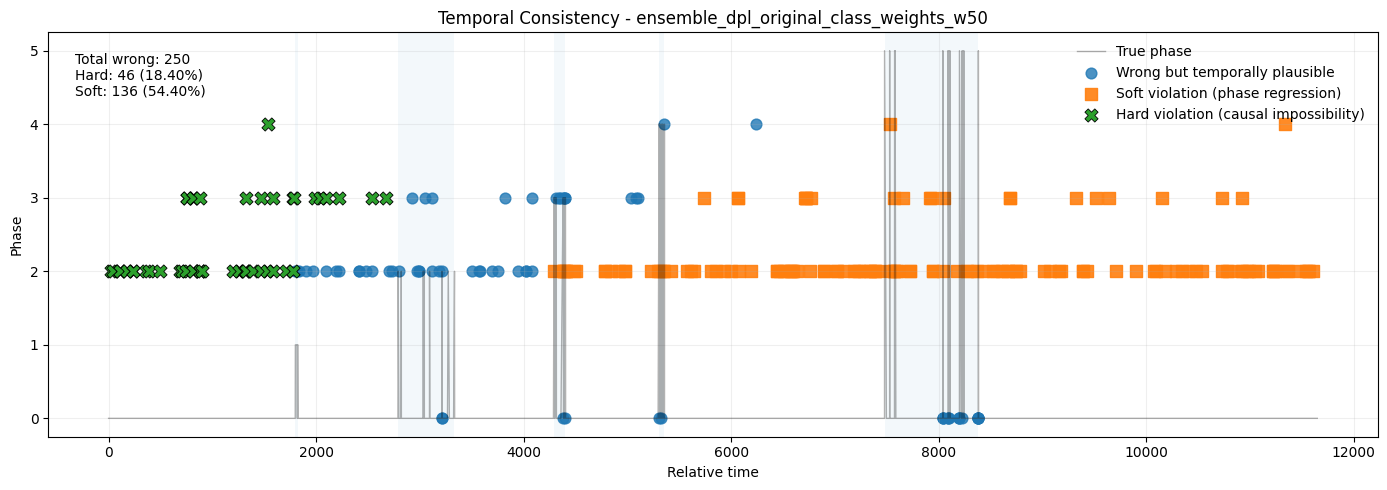

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


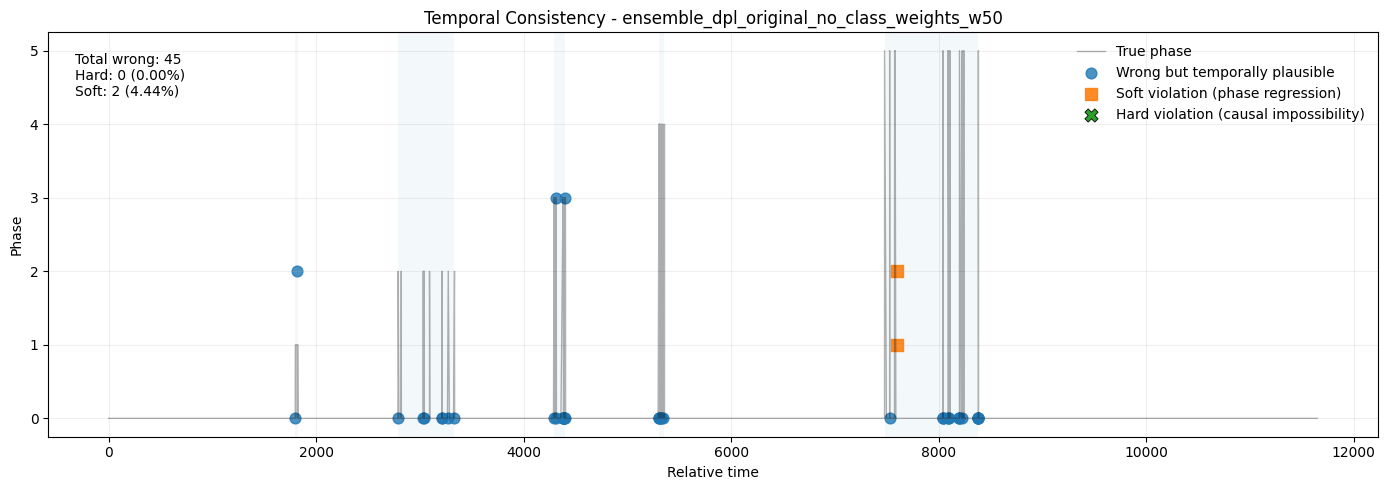

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


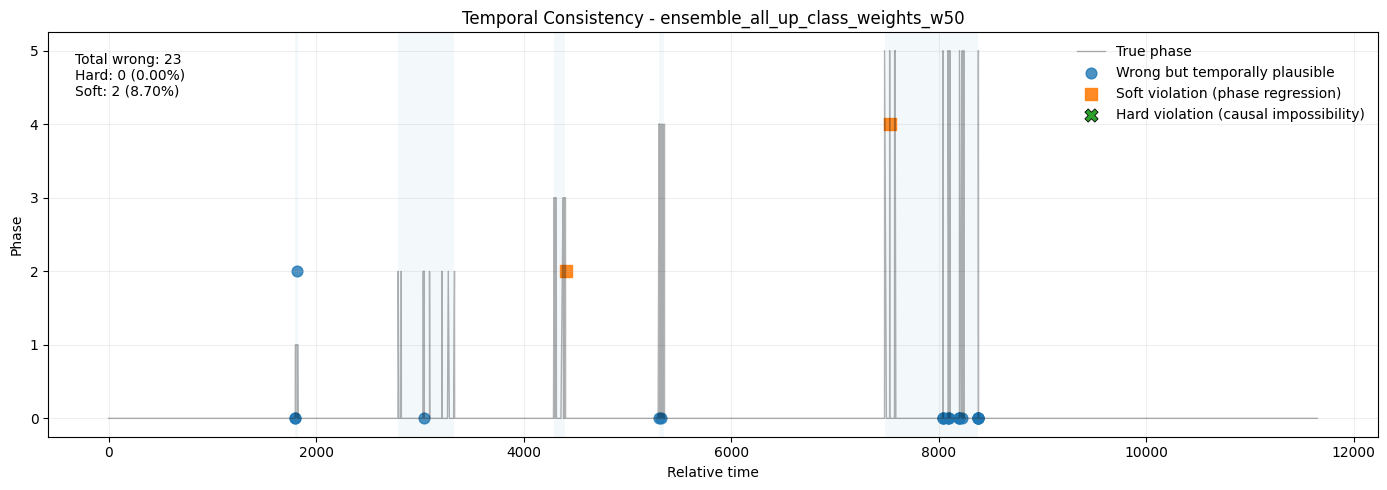

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


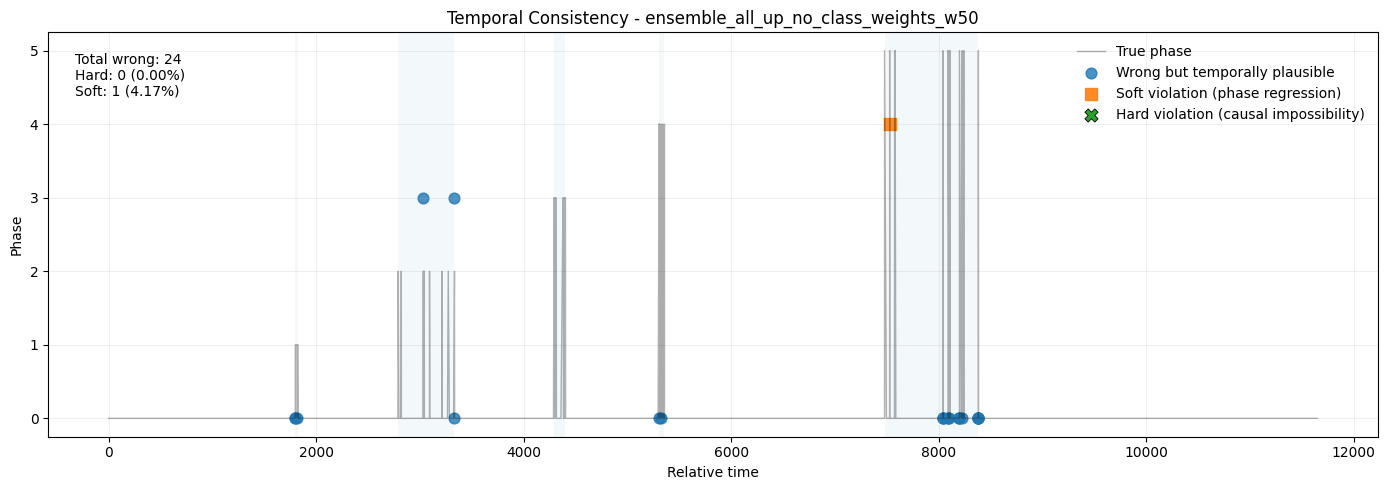

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


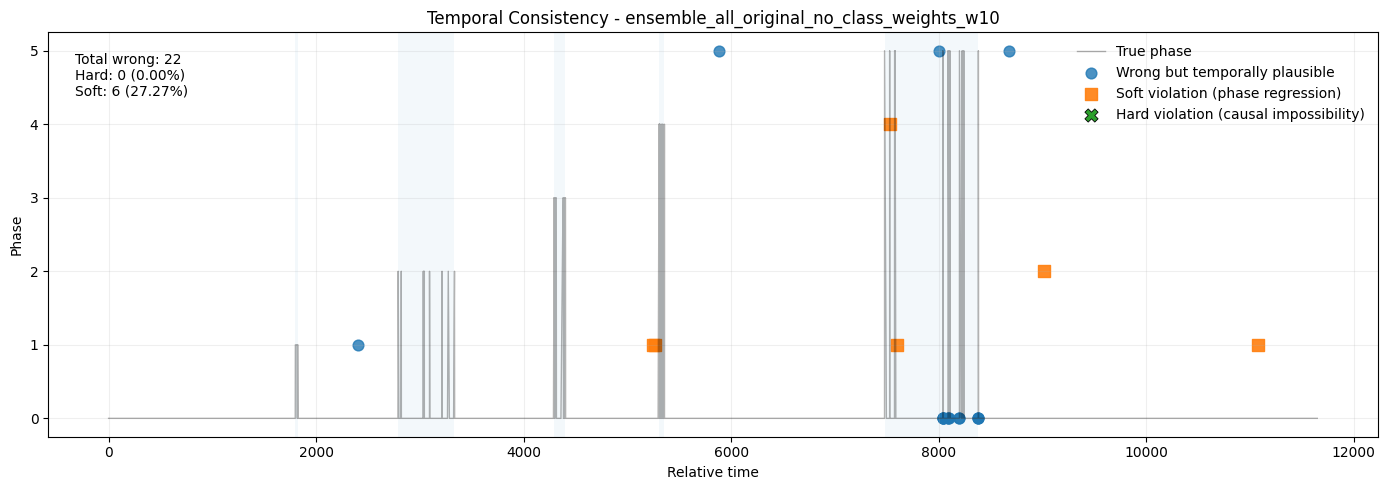

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


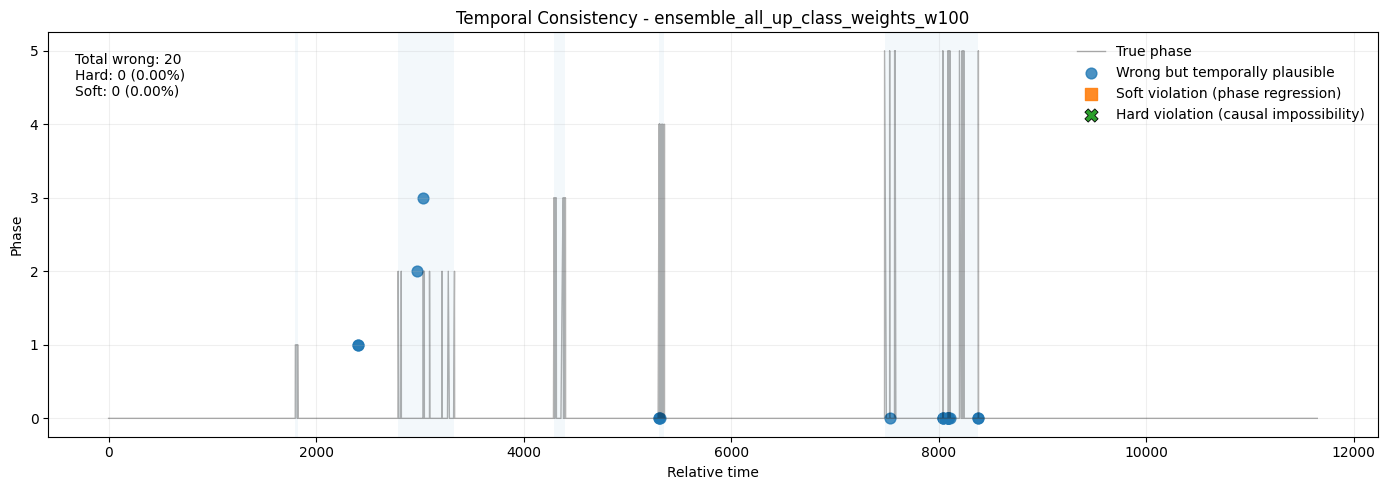

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


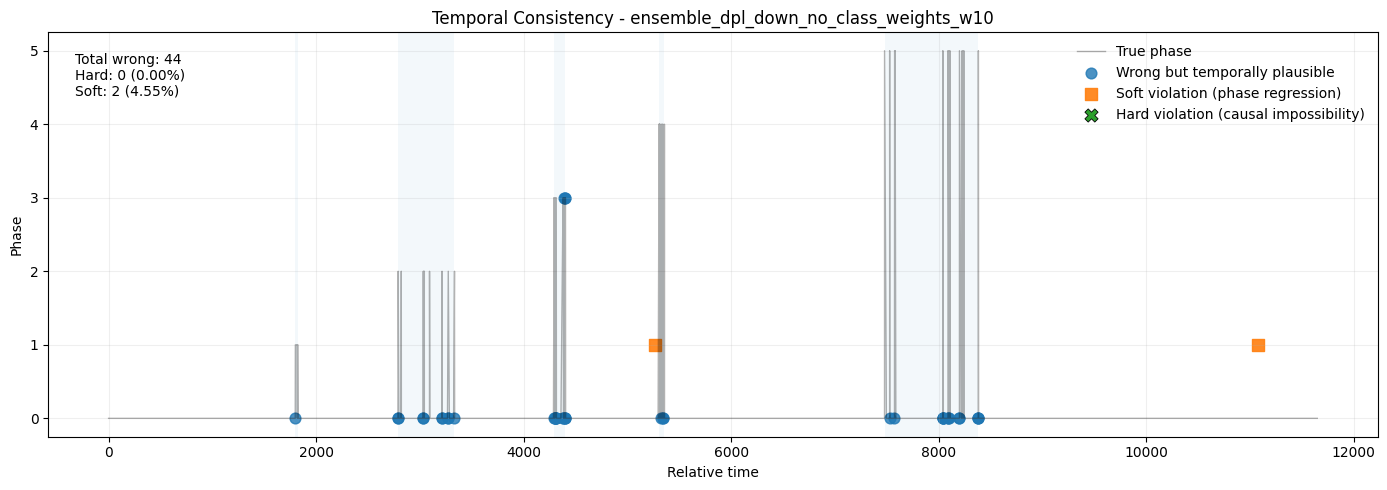

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


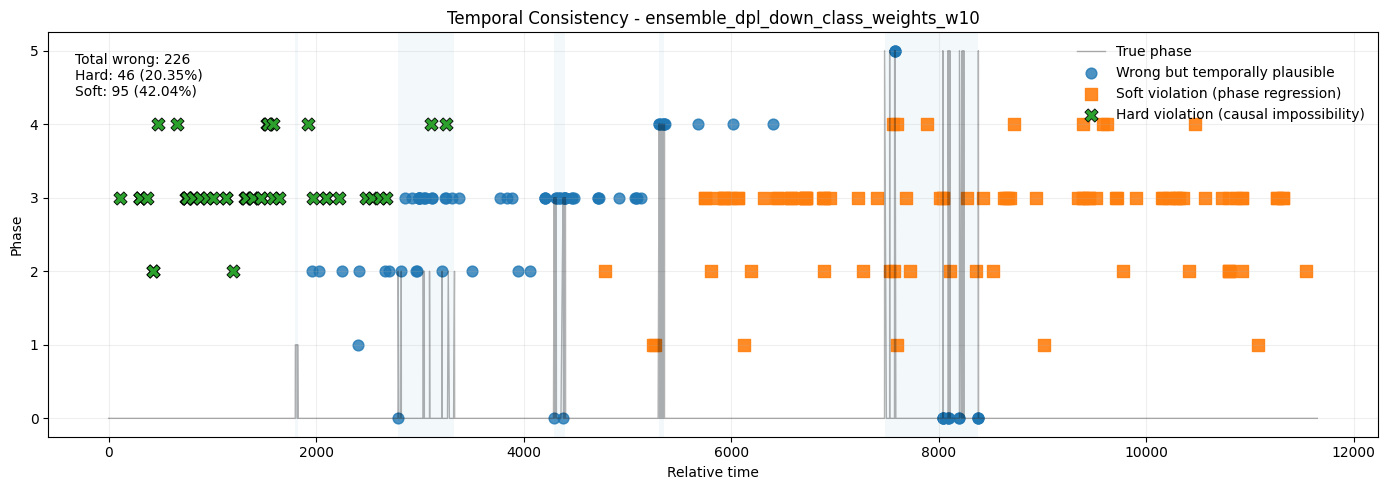

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


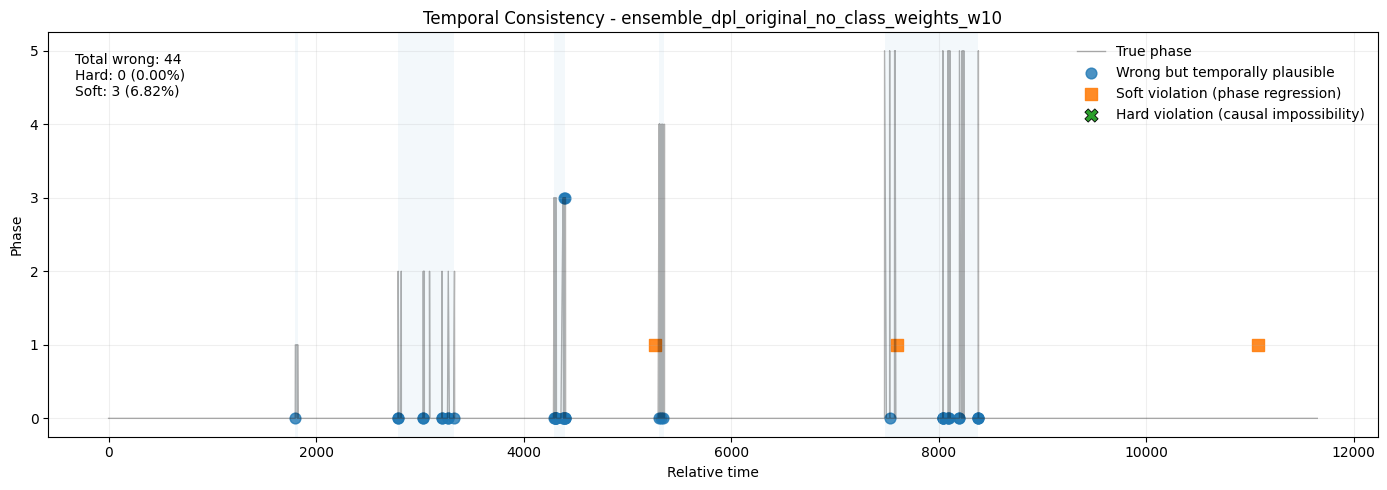

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


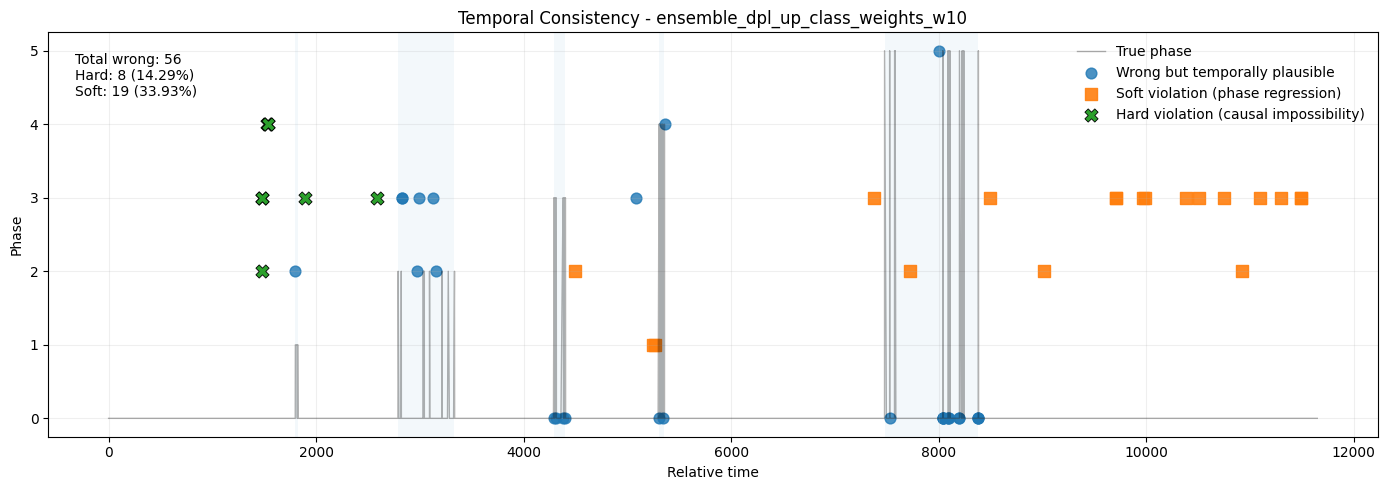

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


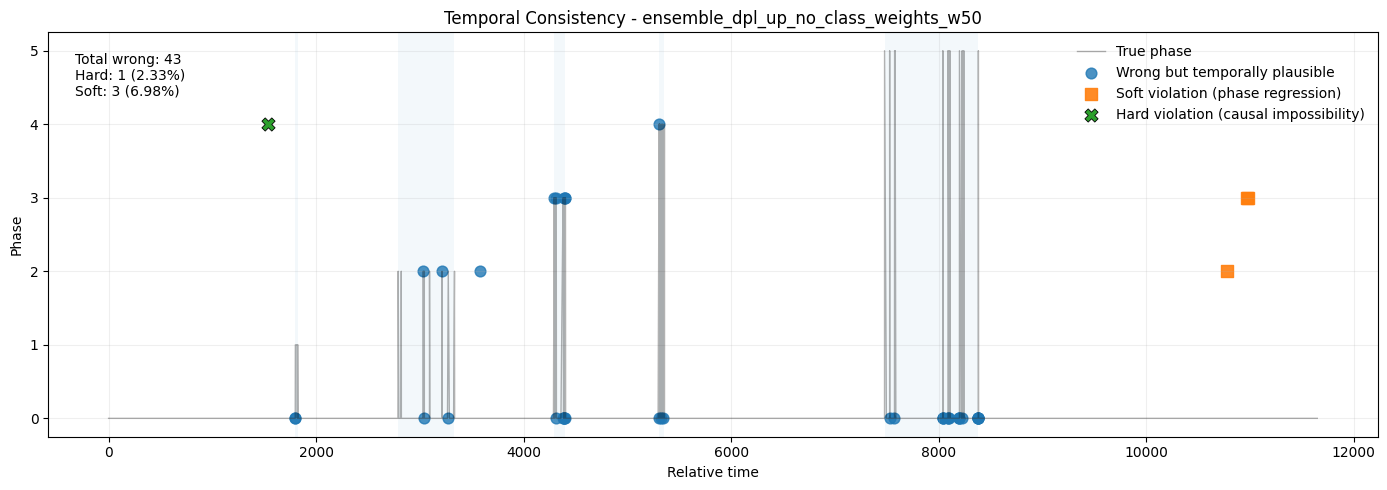

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


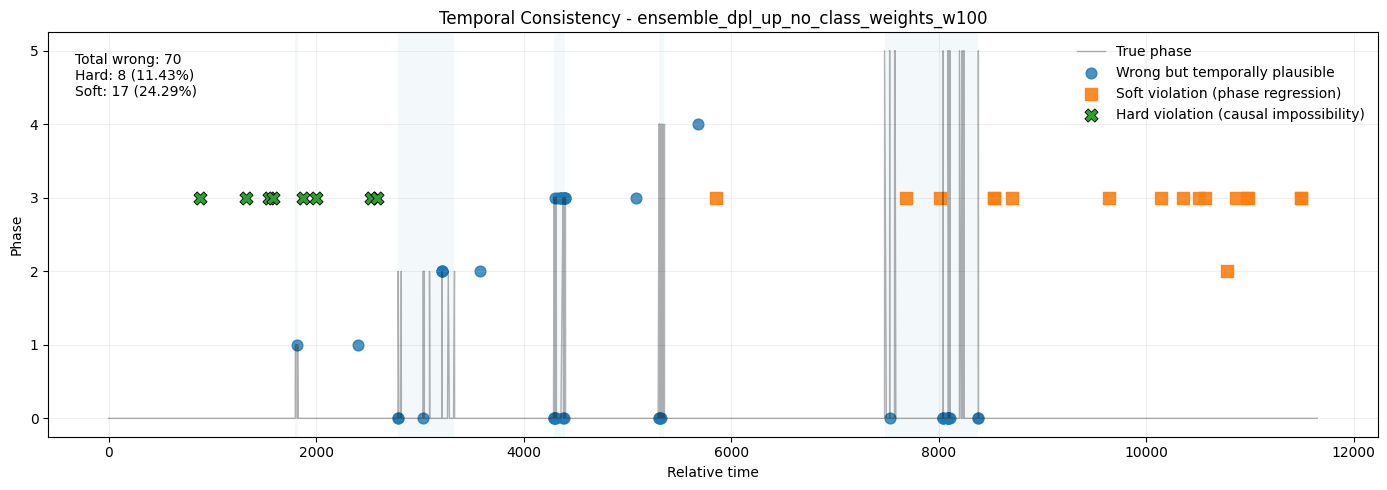

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


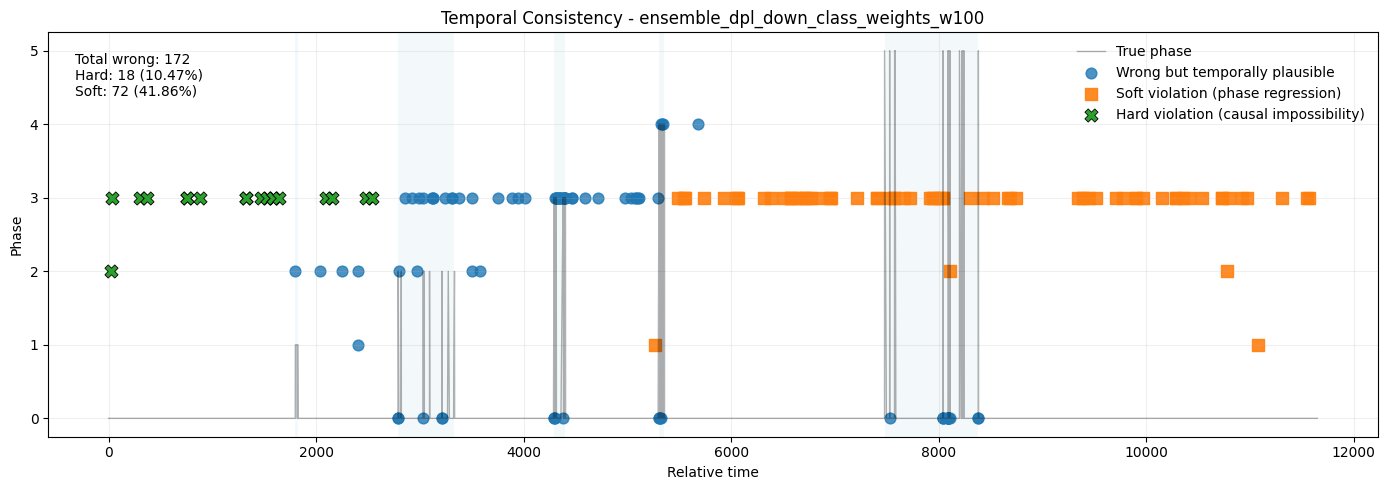

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


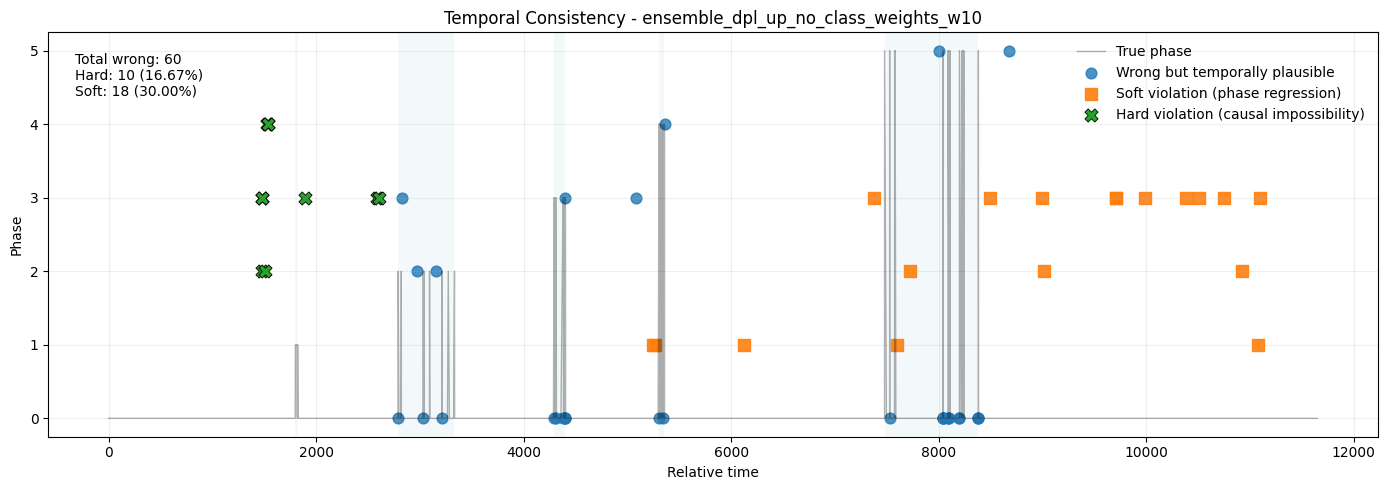

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


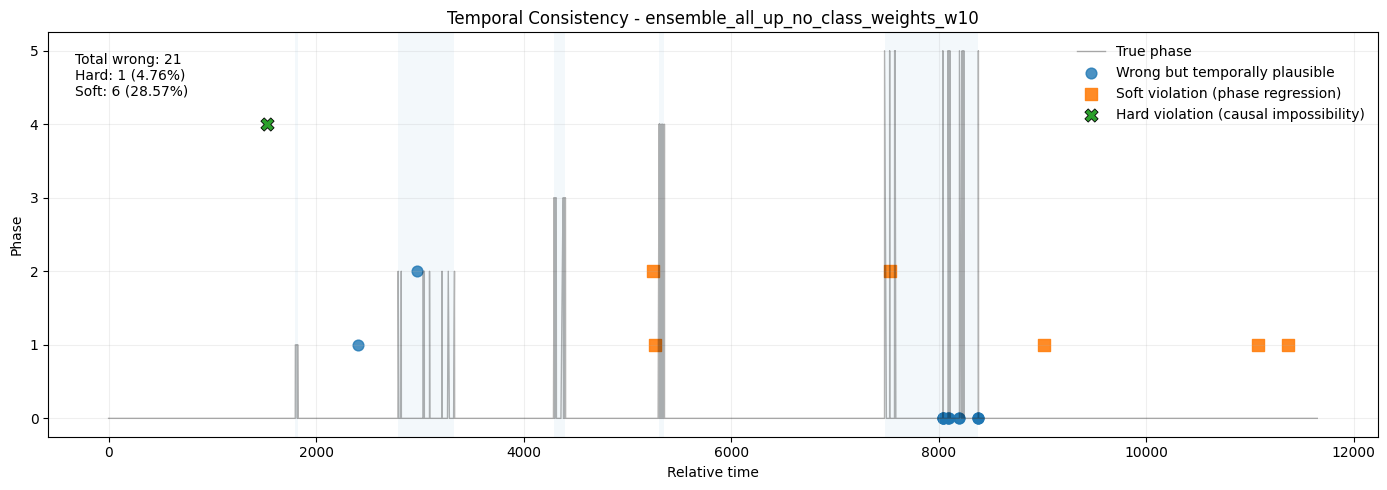

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


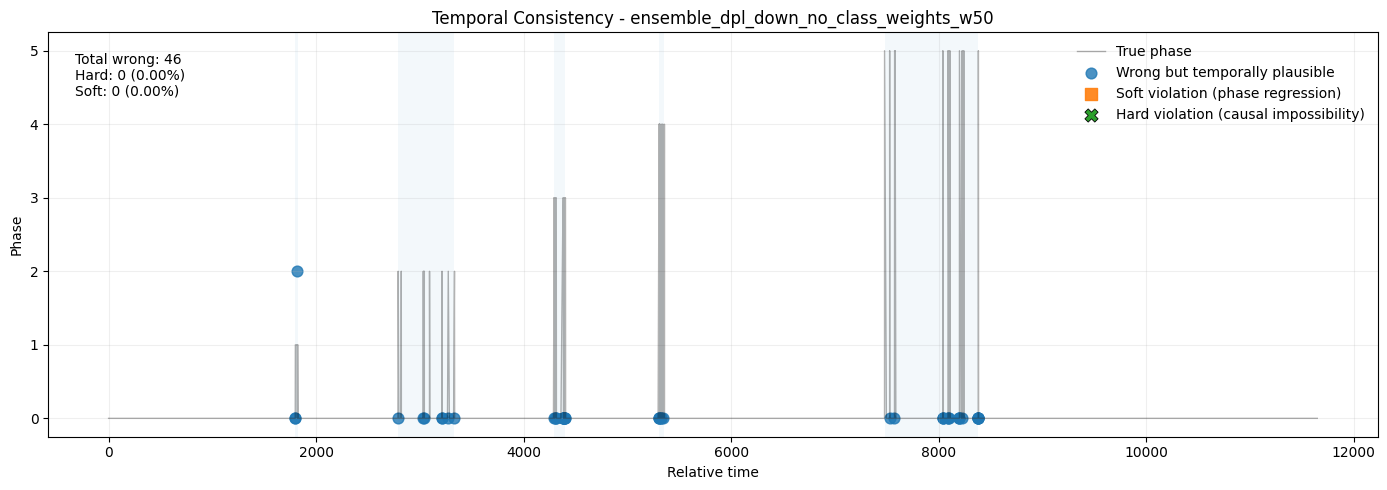

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


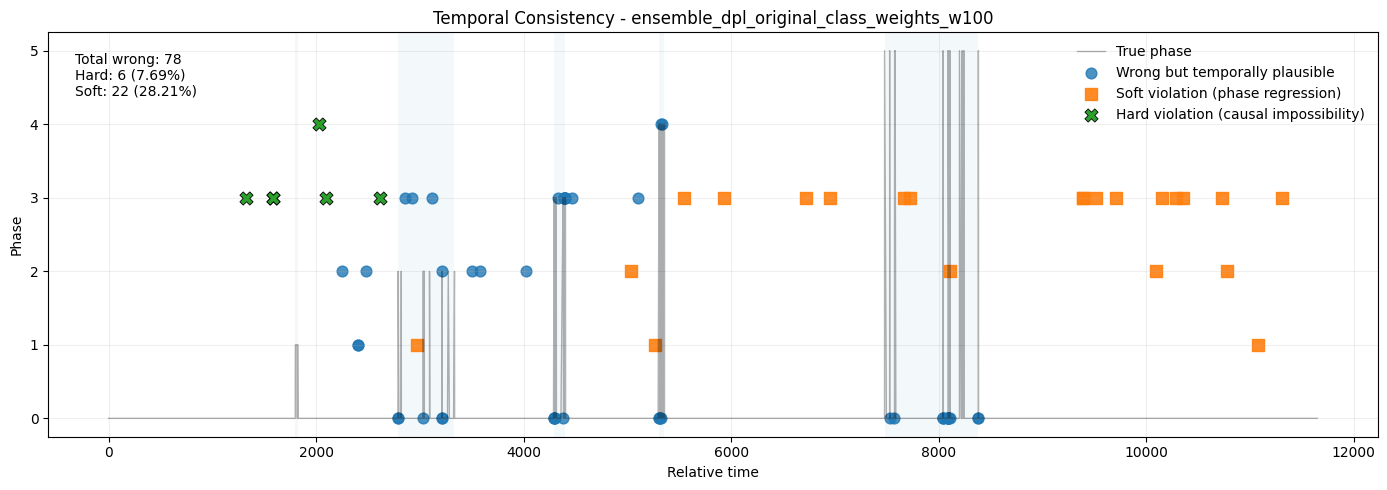

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


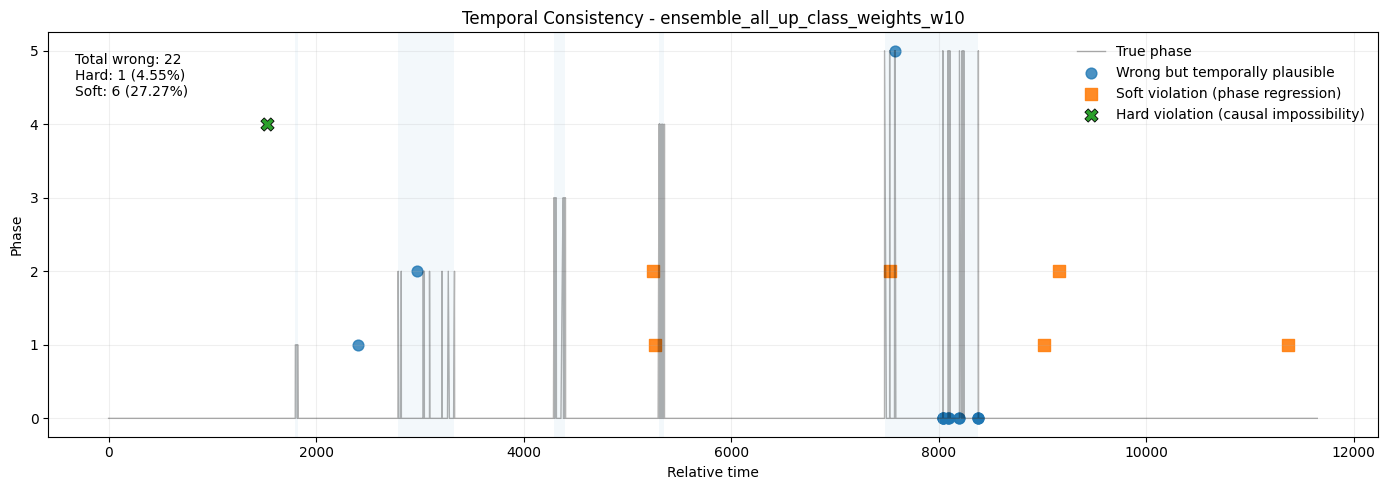

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


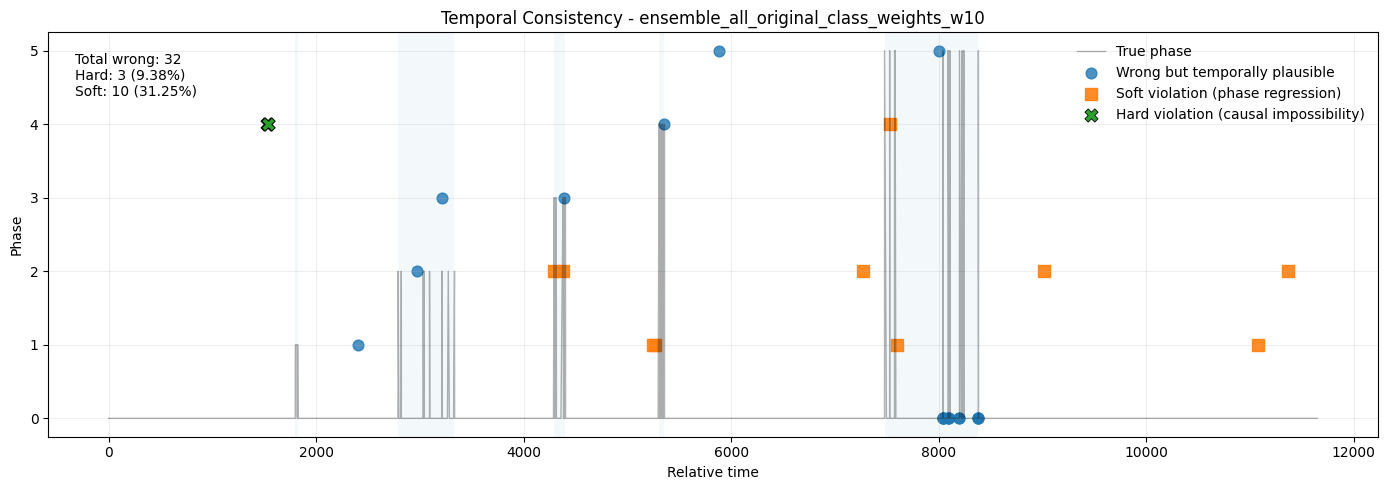

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


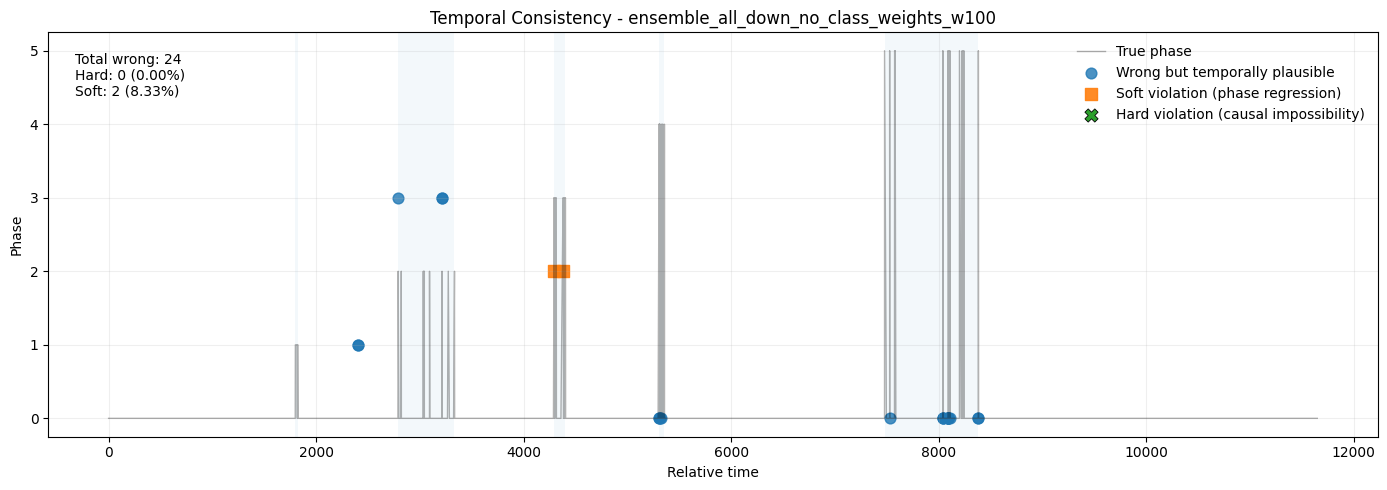

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


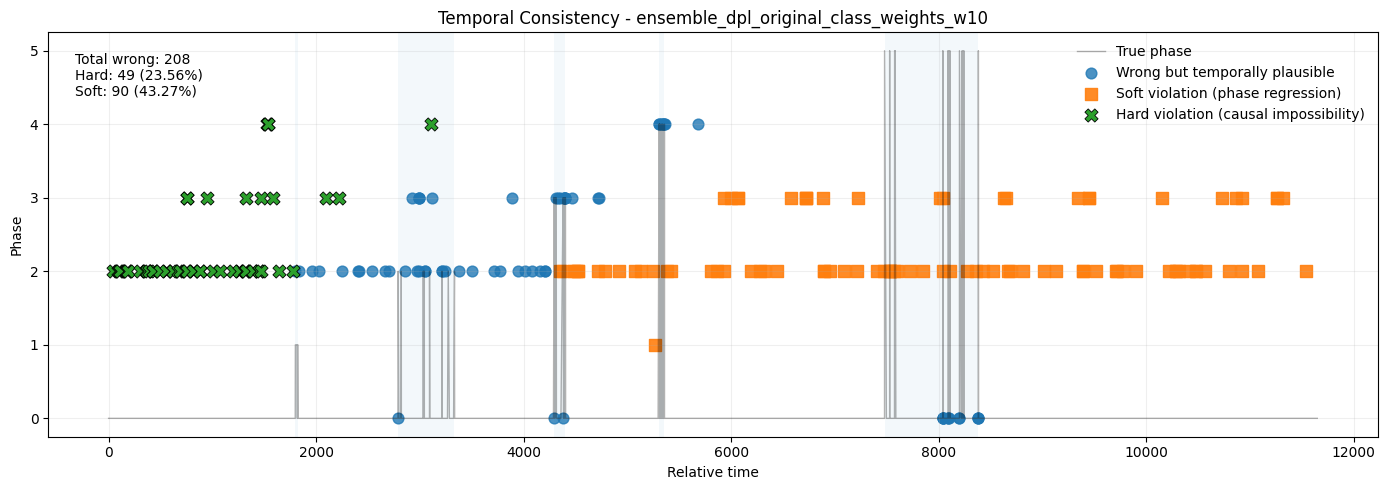

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


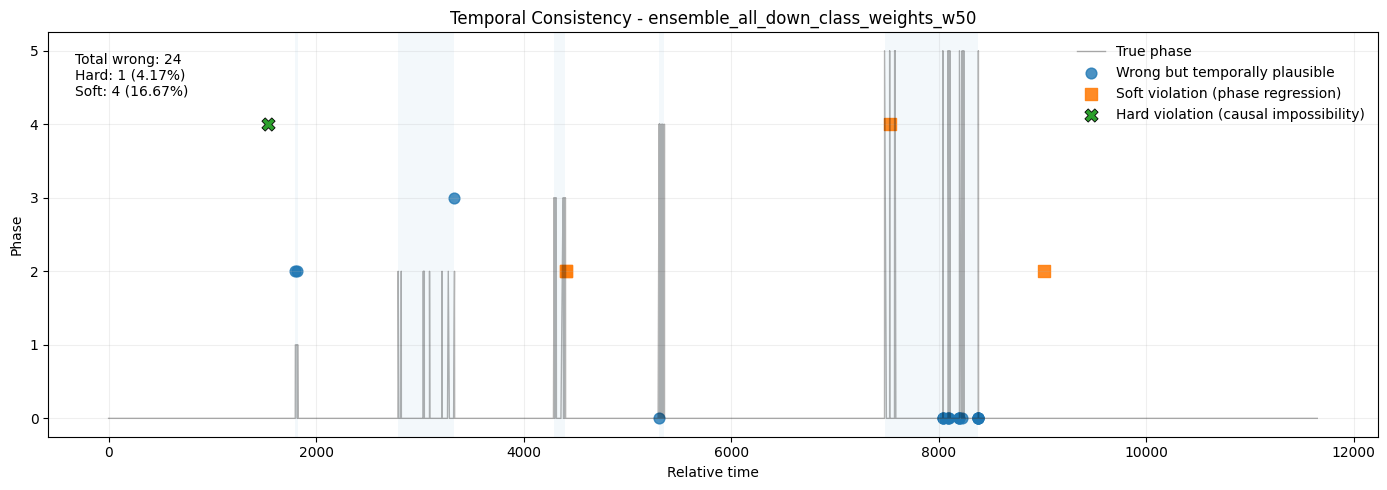

Saving plot to ../reports/baselines/darpa2000/s1_inside/temp...


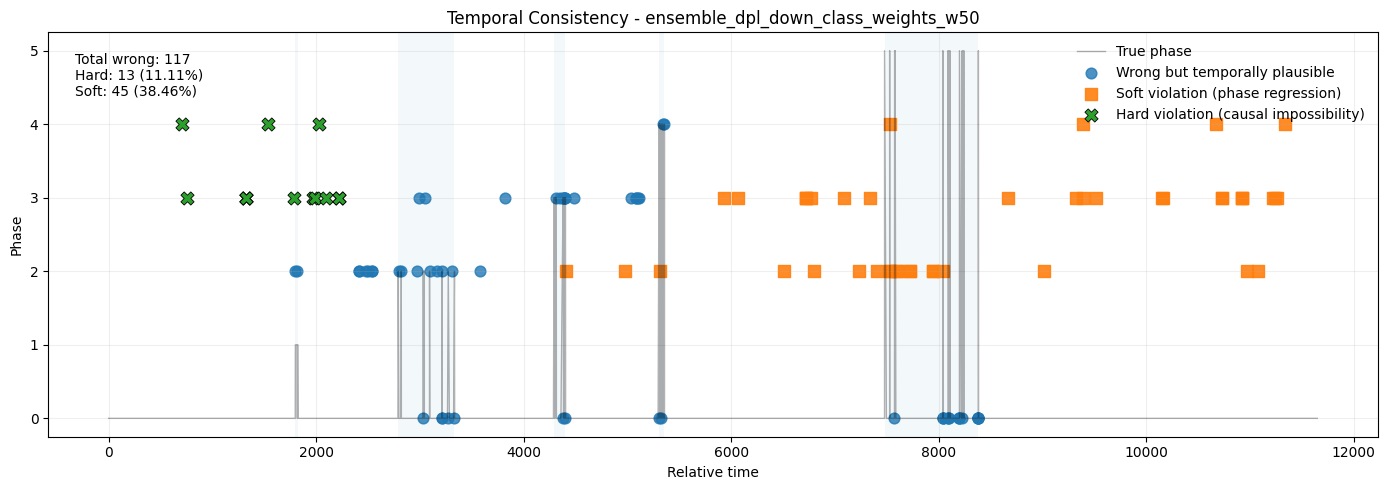

In [8]:
results = []

for file_path in file_paths:

    with open(file_path) as f:
        metrics = json.load(f)

    experiment_name = file_path.stem[:-8]  # Remove "_metrics" suffix

    if "multi_class" in experiment_name:
        model = "multi_class"
    elif "ensemble" in experiment_name:
        model = "ensemble"

    # --- Load misclassification info ---
    real_flow_indices = metrics["real_flow_indices"]
    mis_y_pred = metrics["y_pred"]
    mis_y_true = metrics["y_true"]

    mis_df = df.iloc[real_flow_indices].copy()
    mis_df["y_true"] = mis_y_true
    mis_df["y_pred"] = mis_y_pred

    # --- Compute violation categories ---
    wrong, hard, soft, plausible = mis_metrics(mis_df, phase_start)

    total_wrong = len(wrong)
    hard_rate = len(hard) / total_wrong if total_wrong > 0 else 0
    soft_rate = len(soft) / total_wrong if total_wrong > 0 else 0

    # --- Collect everything ---
    results.append({
        "model": f"{experiment_name}",
        "accuracy": metrics["Accuracy"],
        "precision" : metrics["Macro Precision"],
        "recall" : metrics["Macro Recall"], 
        "f1": metrics["Macro F1"],
        "total_wrong": total_wrong,
        "hard_violations": len(hard),
        "soft_violations": len(soft),
        "hard_rate": hard_rate,
        "soft_rate": soft_rate,
    })

    # Create plots
    plot_mis_predictions(df, phase_bounds, plausible, soft, hard, total_wrong, soft_rate, hard_rate, experiment_name, out_dir)

## Metrics for All Models

In [9]:
results_df = pd.DataFrame(results)

results_df

,model,accuracy,precision,recall,f1,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate
0,multiclass_subfeatures_5data_w10,0.972897,0.372006,0.819932,0.397126,1364,282,738,0.206745,0.541056
1,multiclass_allfeatures_5data_w10,0.997834,0.543365,0.968760,0.640001,109,15,41,0.137615,0.376147
2,multiclass_allfeatures_100data_w10,0.999404,0.803600,0.874184,0.832200,30,1,5,0.033333,0.166667
3,multiclass_allfeatures_10data_w10,0.999126,0.720074,0.926964,0.794949,44,3,5,0.068182,0.113636
4,ensemble_all_up_no_class_weights_w100,0.999582,0.936901,0.886146,0.890432,21,0,0,0.000000,0.000000
5,ensemble_all_down_class_weights_w100,0.999423,0.832223,0.907584,0.850094,29,0,8,0.000000,0.275862
6,ensemble_all_down_class_weights_w10,0.999503,0.829345,0.955212,0.873943,25,1,7,0.040000,0.280000
7,ensemble_dpl_original_no_class_weights_w100,0.999205,0.912205,0.599439,0.666282,40,0,0,0.000000,0.000000
8,ensemble_all_original_class_weights_w100,0.999443,0.828074,0.857338,0.834097,28,0,4,0.000000,0.142857
9,ensemble_all_down_no_class_weights_w10,0.999603,0.893878,0.981362,0.931178,20,0,5,0.000000,0.250000


In [10]:
results_df["temporal_score"] = (
    results_df["f1"]
    - 0.5 * results_df["hard_rate"]
    - 0.2 * results_df["soft_rate"]
)

In [11]:
results_df_sorted_f1 = results_df.sort_values("f1", ascending=False)

# Save metrics to file
results_df_sorted_f1.to_csv(
    f"{out_dir}/temporal_consistency_summary.csv",
    index=False
)

In [12]:
results_df_sorted_f1.head()

,model,accuracy,precision,recall,f1,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate,temporal_score
21,ensemble_all_original_no_class_weights_w10,0.999563,0.898285,0.999855,0.940305,22,0,6,0.000000,0.272727,0.885760
9,ensemble_all_down_no_class_weights_w10,0.999603,0.893878,0.981362,0.931178,20,0,5,0.000000,0.250000,0.881178
31,ensemble_all_up_no_class_weights_w10,0.999583,0.873302,0.999862,0.925280,21,1,6,0.047619,0.285714,0.844328
34,ensemble_all_up_class_weights_w10,0.999563,0.872228,0.999855,0.925129,22,1,6,0.045455,0.272727,0.847856
22,ensemble_all_up_class_weights_w100,0.999602,0.936909,0.909955,0.911649,20,0,0,0.000000,0.000000,0.911649


In [13]:
results_df_sorted_temp = results_df.sort_values("temporal_score", ascending=False)

results_df_sorted_temp.head(10)

,model,accuracy,precision,recall,f1,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate,temporal_score
22,ensemble_all_up_class_weights_w100,0.999602,0.936909,0.909955,0.911649,20,0,0,0.000000,0.000000,0.911649
4,ensemble_all_up_no_class_weights_w100,0.999582,0.936901,0.886146,0.890432,21,0,0,0.000000,0.000000,0.890432
21,ensemble_all_original_no_class_weights_w10,0.999563,0.898285,0.999855,0.940305,22,0,6,0.000000,0.272727,0.885760
9,ensemble_all_down_no_class_weights_w10,0.999603,0.893878,0.981362,0.931178,20,0,5,0.000000,0.250000,0.881178
19,ensemble_all_up_class_weights_w50,0.999543,0.938729,0.871264,0.896632,23,0,2,0.000000,0.086957,0.879241
20,ensemble_all_up_no_class_weights_w50,0.999523,0.951221,0.834235,0.878503,24,0,1,0.000000,0.041667,0.870170
14,ensemble_all_original_no_class_weights_w100,0.999563,0.937119,0.849117,0.865240,22,0,0,0.000000,0.000000,0.865240
34,ensemble_all_up_class_weights_w10,0.999563,0.872228,0.999855,0.925129,22,1,6,0.045455,0.272727,0.847856
31,ensemble_all_up_no_class_weights_w10,0.999583,0.873302,0.999862,0.925280,21,1,6,0.047619,0.285714,0.844328
16,ensemble_all_original_no_class_weights_w50,0.999463,0.960118,0.785293,0.846925,27,0,1,0.000000,0.037037,0.839517


## Analyze Specific Model

In [14]:
# Hyperparameters for best-performing model
model = "multi_class"
features = "all"
dataset_variant = "up"
weights = "no_class_weights"
window_size = 10

In [15]:
processed_dir = f"../data/processed/{dataset}/{scenario}/windowed"
metrics_dir = f"../experiments/{dataset}/{scenario}/baselines/{model}/metrics"

exp_name = f"{model}_{features}_{dataset_variant}_{weights}_w{window_size}"
metrics_file = f"{metrics_dir}/{exp_name}_metrics.json"

In [16]:
with open(metrics_file) as f:
    metrics = json.load(f)

misclassified_indices = metrics["missclassified_indices"]
real_flow_indices = metrics["real_flow_indices"]
mis_y_pred = metrics["y_pred"]
mis_y_true = metrics["y_true"]

mis_df = df.iloc[real_flow_indices].copy()
mis_df["y_true"] = mis_y_true
mis_df["y_pred"] = mis_y_pred


In [17]:
wrong, hard, soft, plausible = mis_metrics(mis_df, phase_start)

total_wrong = len(wrong)

hard_rate = len(hard) / total_wrong if total_wrong > 0 else 0
soft_rate = len(soft) / total_wrong if total_wrong > 0 else 0

print(f"Total wrong: {total_wrong}")
print(f"Hard violations: {len(hard)} ({hard_rate:.2%})")
print(f"Soft violations: {len(soft)} ({soft_rate:.2%})")

Total wrong: 22
Hard violations: 1 (4.55%)
Soft violations: 5 (22.73%)


In [18]:
# out_dir = ""
# plot_mis_predictions(df, phase_bounds, plausible, soft, hard, total_wrong, soft_rate, hard_rate, experiment_name, out_dir, save_plot=False)

In [19]:
mis_only = mis_df[mis_df["y_true"] != mis_df["y_pred"]]

pd.crosstab(
    mis_only["y_true"],
    mis_only["y_pred"],
)

y_pred,0,1,2,3,4,5
y_true,,,,,,
0,0,2,2,0,1,1
2,0,0,0,1,0,0
3,0,0,1,0,0,0
5,13,0,1,0,0,0
